In [16]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import flopy, pyproj, pandas, geopandas, shapely
import matplotlib.pyplot as plt
import matplotlib as mpl
from adjustText import adjust_text # for repelling each text
import cmcrameri
import sys

from flopy.utils.triangle import Triangle
from flopy.utils.voronoi import VoronoiGrid
from shapely.geometry import LineString, Point
from flopy.discretization import VertexGrid
from flopy.utils import Raster
from flopyUtils.utils import wrap_gmsh
from flopyUtils.geometry import ModelIntersect
import flopyUtils
import datetime
print("init path:", sys.path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
init path: ['d:\\flopy', 'c:\\ProgramData\\Anaconda3\\python38.zip', 'c:\\ProgramData\\Anaconda3\\DLLs', 'c:\\ProgramData\\Anaconda3\\lib', 'c:\\ProgramData\\Anaconda3', '', 'C:\\Users\\SUHHO LEE\\AppData\\Roaming\\Python\\Python38\\site-packages', 'c:\\users\\suhho lee\\desktop\\code\\flopy-utils', 'c:\\ProgramData\\Anaconda3\\lib\\site-packages', 'c:\\ProgramData\\Anaconda3\\lib\\site-packages\\flopy-3.7.0.dev0-py3.8.egg', 'c:\\ProgramData\\Anaconda3\\lib\\site-packages\\fonttools-4.49.0-py3.8.egg', 'c:\\ProgramData\\Anaconda3\\lib\\site-packages\\win32', 'c:\\ProgramData\\Anaconda3\\lib\\site-packages\\win32\\lib', 'c:\\ProgramData\\Anaconda3\\lib\\site-packages\\Pythonwin']


EPSG:5186
EPSG:5186


C:\Users\SUHHO LEE\AppData\Local\Temp\ipykernel_8868\1354143343.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(np.array(ax.get_xticks())/1000)
C:\Users\SUHHO LEE\AppData\Local\Temp\ipykernel_8868\1354143343.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.array(ax.get_yticks())/1000)
C:\Users\SUHHO LEE\AppData\Local\Temp\ipykernel_8868\1354143343.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.3))


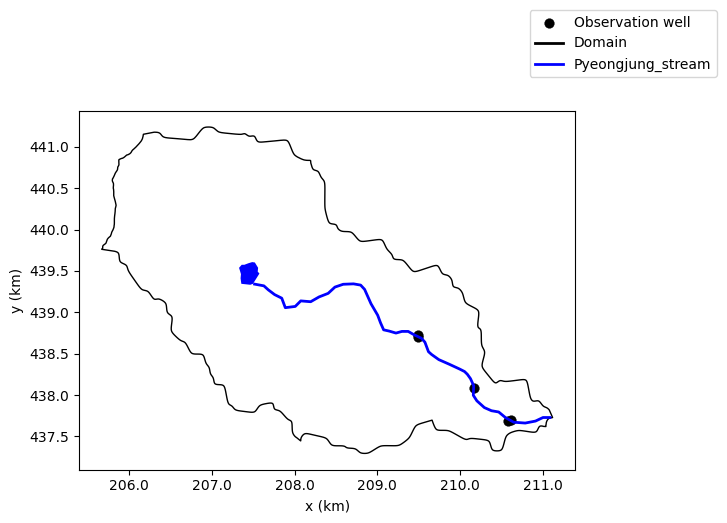

In [17]:
# Load domain
domain = geopandas.read_file('./Pyeongjung/pyeongjeong_5181.shp').to_crs(5186)
print(domain.crs)
# Load stream lines
stream = geopandas.read_file('./Pyeongjung/river_arcs.shp').to_crs(5186)
print(stream.crs)
# Load well points
points = pandas.read_csv('./Pyeongjung/Observation_2.csv')
# Load lakㄷ
lake_2 = geopandas.read_file('./Pyeongjung/Lake_5186.shp').to_crs(5186) #양화
# Draw figure
fig, ax = plt.subplots()
domain.plot(ax=ax,facecolor='none')
stream.plot(ax=ax,edgecolor='b',lw=2)
ax.scatter(points['X'], points['Y'], 50, marker='o', color='k', label='Observation well', lw=0.2)
lake_2.plot(ax=ax,facecolor='b', label='Lake')
#ax.scatter(points['x'], points['y'], 50, marker='+', color='r', label='GW obs.', lw=2)
ax.plot([],[], color='k',lw=2, label='Domain') # dummy plot for model domain
ax.plot([],[], color='b',lw=2, label='Pyeongjung_stream') # dummy plot for stream boundary
ax.set_xticklabels(np.array(ax.get_xticks())/1000)
ax.set_yticklabels(np.array(ax.get_yticks())/1000)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.3))
#fig.tight_layout()

In [ ]:
mesh = wrap_gmsh.Gmsh()
# Add observation points for refinement
mesh.add_point(np.vstack((points['X'], points['Y'])).T, 100)
# Add stream

for geom in stream.geometry:
    if geom is not None:
        mesh.add_line(geom,100)

geom = domain.geometry[0]
domain_xy = np.vstack((geom.exterior.xy[0], geom.exterior.xy[1])).T

if 1:
    tmp = mesh.generate_gmsh(domain_xy, clmax=2000, verbose=30, use_internal=5)
else:
    print('Read mesh')
    mesh.readgmsh('./temp.msh', verbose=1)
print(mesh)
tri = mesh.to_flopy_triangle()


add outer polygon.
add outer lines.
add line loop
add surface!
write geo file.
generate mesh!
   use internal mesh generation.
write mesh



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


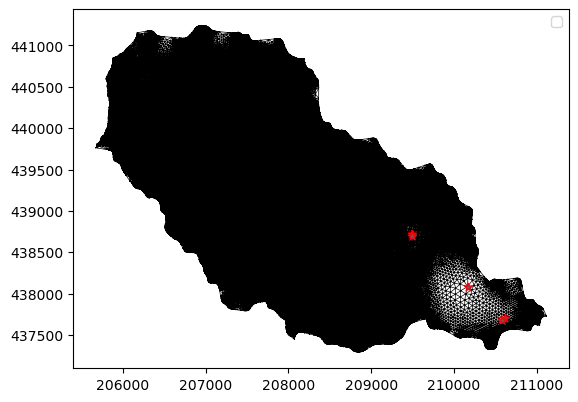

In [ ]:
_xy = np.array(mesh._polygons[0])

#matplotlib widget
fig, ax = plt.subplots()
mesh.plot(ax=ax, lw=.5, color='k')
#lake_2.plot(ax=ax,facecolor='b', label='Lake')
#stream.plot(ax=ax, edgecolor='b', lw=2)
#ax.scatter(_xy[:,0], _xy[:,1], marker='+', edgecolor='r')
ax.scatter(points['X'],points['Y'],marker='*',edgecolor='r')
ax.legend()

In [ ]:
vor = VoronoiGrid(tri)
gridprops = vor.get_gridprops_vertexgrid()
voronoi_grid = VertexGrid(**gridprops, nlay=2,
                         crs=5186)
print(f'   epsg: {voronoi_grid.epsg}')
print(vor.iverts[0])
print(vor.iverts[1])
print(vor.verts[1])
print(len(voronoi_grid.verts))
print(len(voronoi_grid.iverts))
print(len(vor.points))

   epsg: 5186
[187951, 187952, 187948, 72943, 101011]
[101032, 187948, 187955, 187954, 145474, 145473]
[210418.39793999 437328.31806758]
191722
94692
94692


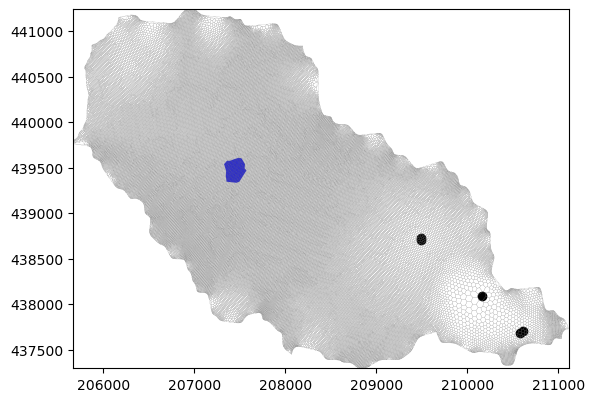

In [ ]:
fig, ax = plt.subplots()
voronoi_grid.plot(ax=ax,lw=.1)
lake_2.plot(ax=ax,facecolor='b', label='Lake')
stream.plot(ax=ax, color='b')
ax.scatter(points['X'],points['Y'],marker='o',color='k', edgecolor='k')

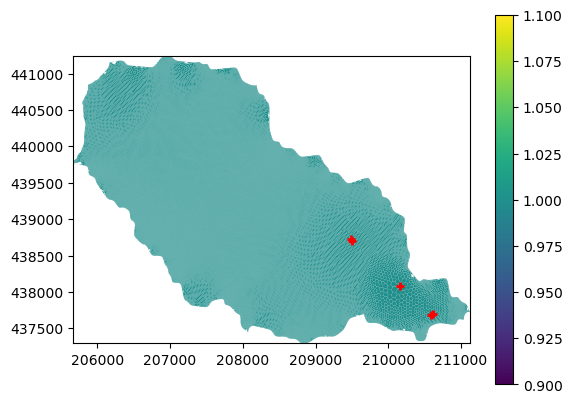

In [ ]:
tic = datetime.datetime.now()
mi = ModelIntersect(vor)
idomain_vor = np.zeros((1,len(mi.polygon)), dtype=int)

if 1:
    stream = geopandas.read_file('./Pyeongjung/river_arcs.shp')
    pos_stream_all = np.zeros(np.shape(mi.polygon), dtype=bool)
    for geo in stream.geometry:
        if geom is not None:
            pos_stream = mi.intersect(geom)
            pos_stream_all[pos_stream] = 1

    idomain_vor[0, np.where(pos_stream_all)] = 1

# Matplotlib gogo
fig, ax = plt.subplots()
pmv = flopy.plot.PlotMapView(modelgrid=voronoi_grid)
im = pmv.plot_array(idomain_vor)
fig.colorbar(im, ax=ax)
stream.plot(ax=ax, lw=2, color='k')

ax.scatter(points['X'], points['Y'], marker = '+', color='r', lw=2)

# Add DEM to the layer

In [ ]:
top = flopyUtils.interp.interpGeotiffToModel('./Pyeongjung/Elevation_PJ.tif', voronoi_grid, verbose=0,)
#top = pandas.read_csv('./Noseong/mf_input/mf.disv_TOP_1.csv')
#top_1 = top.to_numpy()
#top_1 = top_1.reshape(1, 4756)
#print(top_1)
print(f'   top size {np.shape(top)}')

(94692, 2)
   top size (94692,)


C:\Users\SUHHO LEE\AppData\Local\Temp\ipykernel_8868\1658479297.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(np.array(ax.get_xticks())/1000)
C:\Users\SUHHO LEE\AppData\Local\Temp\ipykernel_8868\1658479297.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.array(ax.get_yticks())/1000)


   elevation


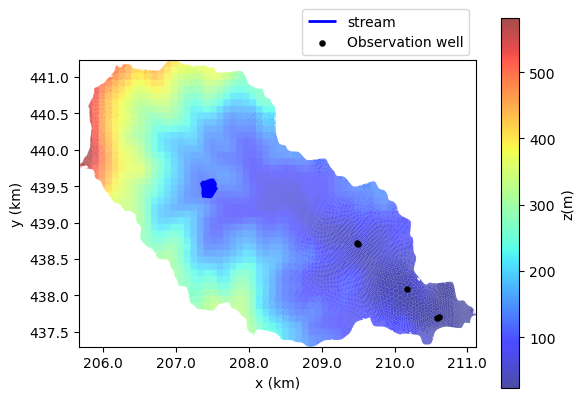

In [ ]:
fig, ax = plt.subplots()
pmv = flopy.plot.PlotMapView(modelgrid=voronoi_grid)
im = pmv.plot_array(top, cmap="jet", vmin=np.amin(top), vmax=np.amax(top), alpha=0.7)
fig.colorbar(im, ax=ax, label = 'z(m)')
stream.plot(ax=ax, color='b', lw=2, label='stream')
#tributary.plot(ax=ax,edgecolor='g',lw=2, label='tributary')
ax.scatter(points['X'], points['Y'], 20, marker='o', color='k', label='Observation well', lw=0.2)
#lake_1.plot(ax=ax,facecolor='b', label='계룡')
lake_2.plot(ax=ax,facecolor='b')

ax.set_xticklabels(np.array(ax.get_xticks())/1000)
ax.set_yticklabels(np.array(ax.get_yticks())/1000)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.legend(loc='upper right', bbox_to_anchor=(1.0,1.2))

print(f'   elevation')
#print(f'   max {np.amax(top):.2f}')
#print(f'   min {np.amin(top):.2f}')
#fig.savefig('./Pyeongjung/elevation.tif', dpi=400)

# Original run for model - but this has some limitations for reflecting specified conditions

In [ ]:
name = "mf"
model_ws = './Pyeongjung/model'
sim = flopy.mf6.MFSimulation(sim_name=name, version="mf6", exe_name="mf6", sim_ws=model_ws)
tdis = flopy.mf6.ModflowTdis(sim, time_units="DAYS", perioddata=[[1, 1, 1.]],
   start_date_time='2023-01-01',)
gwf = flopy.mf6.ModflowGwf(sim, modelname=name, save_flows=True,)
ims = flopy.mf6.ModflowIms(sim, print_option="SUMMARY", complexity="complex",linear_acceleration = "BICGSTAB",)
cell2d = vor.get_disv_gridprops()['cell2d']
vertices = vor.get_disv_gridprops()['vertices']
xy = np.array(vertices)
nlay=2
ncpl = vor.get_disv_gridprops()['ncpl']
nvert = vor.get_disv_gridprops()['nvert']
botm1 = top - 25.5 # uniform top layer
#botm2 = np.linspace(botm1, 0, nlay)
botm = botm1
dis = flopy.mf6.ModflowGwfdisv(
    gwf,
    nlay=nlay,
    ncpl=ncpl,
    nvert=nvert,
    top=top,
    botm=botm,
    vertices=vor.get_disv_gridprops()['vertices'],
    cell2d=vor.get_disv_gridprops()['cell2d'],
)

# NPF package -> Node property information
npf = flopy.mf6.ModflowGwfnpf(gwf, xt3doptions=[(True)], save_saturation=True, save_specific_discharge=None, icelltype=1,k=21.0, k22=10.8, k33=0.9)
ic = flopy.mf6.ModflowGwfic(gwf, strt=300.0)

#Set recharge
rch_rate = 1.71e-5
flopy.mf6.ModflowGwfrcha(gwf, recharge=rch_rate)
'''
# Load package
riv = gwf.load_package(ftype='riv', fname='mf.riv', pname='riv', strict=True, ref_path=None)
# List all packages associated with the model
pkg_list = gwf.package_names
print("Attached packages:", pkg_list)

riv = flopy.mf6.ModflowGwfriv(gwf,
                              pname="riv",
                              print_input=True,
                              print_flows=True,
                              save_flows="mf.cbc",
                              boundnames=True)

drain_tri = geopandas.read_file('./Noseong/Data/Noseong_tributary.shp')
pos_all = np.zeros(np.shape(mi.polygon), dtype=bool)
for geom in drain_tri.geometry:
   if geom is not None:
      pos = mi.intersect(geom)
      pos_all[pos] = 1
drain_tri_cells = np.where(pos_all)[0]
drn_spd    = []
drn_depth  = 10.0    # drainage depth (unit: meter)
drn_hk     = 50   # vertical hydraulic conductivity (unit: m/day)
drn_bed_thk= 1.0    # vertical drainage thickness (unit: meter)
for idx in drain_tri_cells:
   drn_spd.append([0, idx, 300, 1000, -drn_depth])
drn = flopy.mf6.ModflowGwfdrn(gwf,
                              auxiliary=["depth"],
                              auxdepthname="depth",
                              stress_period_data=drn_spd)
'''
# Set constant head boundary -> Need to be explained
chd_period = [1, 72, 100]
flopy.mf6.ModflowGwfchd(gwf, stress_period_data={0:chd_period})

# Set output file
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    budget_filerecord=f"{name}.cbc",
    head_filerecord=f"{name}.hds",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],)
if 1:
   sim.write_simulation(silent=1)
   success, buff = sim.run_simulation(report=True, silent=0)
   assert success
   print('done')


MFDataException: An error occurred in data element "botm" model "mf" package "disv". The error occurred while setting data in the "__init__" method.
Additional Information:
(1) Unable to set data "botm" layer 0.  Data is not in a valid format.
(2) Error occurred while adding dataset "botm" to block "griddata"

# Visualization

[[134.01914377 132.06064126 129.47265299 ...  25.6613836   64.01819035
   46.09526175]]
-1e+30
158.45150561264185


NotImplementedError: must define get_plottable_layer_array in child class

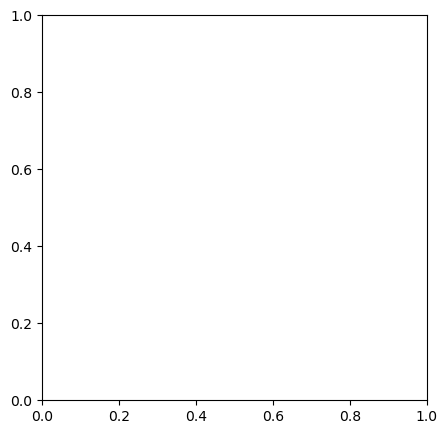

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

name = "flow"
model_ws = './Pyeongjung/model'
sim = flopy.mf6.MFSimulation(sim_name=name, version="mf6", exe_name="mf6", sim_ws=model_ws)
gwf = flopy.mf6.ModflowGwf(sim, modelname=name, save_flows=True,)

# Read head file
hds = flopy.utils.binaryfile.HeadFile('./Pyeongjung/model/mf/MODFLOW 6/sim/flow_output/flow.hds')
h = hds.get_data(kstpkper=(0,0), mflay=2)
print(h)
print(np.amin(h))
print(np.amax(h))
fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 1, 1, aspect="equal")
pmv = flopy.plot.PlotMapView(gwf)
k = pmv.plot_array(h, cmap="jet", vmin=0.0, vmax=120.0)
stream.plot(ax=ax, color='b', lw=2, label='stream')
ax.scatter(points['X'].values, points['Y'].values, 14, marker='o',color='k',label='Observation',edgecolor='k')
ax.legend(bbox_to_anchor=(1.15,1.15))
plt.colorbar(k, shrink=0.5)
#plt.savefig('./Pyeongjung/model.tif', transparent=True, dpi=400)

#h1=h.reshape(10560,1)
h = pd.DataFrame(h1)
h.to_csv('./Pyeongjung/head.csv')


# Estimate the baseflow using exchange flux concept

In [ ]:
import flopy
import numpy as np
import pandas

cbc_file = './Pyeongjung/model/mf/MODFLOW 6/sim/flow_output/flow.cbc'
cbc = flopy.utils.CellBudgetFile(cbc_file, precision='double')
# List all available record names to identify the RIV flux term
print("Available record names in the CBC file:")
print(cbc.get_unique_record_names())

riv_flux = cbc.get_data(text='RIV')
# Store RIV flux data by time step
riv_flux_sum = []

# Loop through each time step to calculate the total RIV-RIV flux
for ts, flux_array in enumerate(riv_flux):
    # Calculate the total flux by summing the 'q' (flux values) for each time step
    total_flux = np.sum(flux_array['q'])
    riv_flux_sum.append(total_flux)
    print(f"Time step {ts + 1}: Total RIV-RIV flux = {total_flux:.4f} cubic meters/day")

# Create a DataFrame to store the time series of RIV fluxes
time_series_df = pandas.DataFrame({
    'Time Step': np.arange(1, len(riv_flux_sum) + 1),
    'RIV-RIV Flux (cubic meters/day)': riv_flux_sum
})

# Print the time series DataFrame
print(time_series_df)

# Optionally, save the time series data to a CSV file
time_series_df.to_csv('./Pyeongjung/model/mf/MODFLOW 6/sim/flow_output/baseflow.csv', index=False)

Available record names in the CBC file:
[b'    FLOW-JA-FACE', b'             RIV', b'             GHB', b'             RCH']
Time step 1: Total RIV-RIV flux = -49217.7055 cubic meters/day
Time step 2: Total RIV-RIV flux = -47701.3220 cubic meters/day
Time step 3: Total RIV-RIV flux = -46200.6708 cubic meters/day
Time step 4: Total RIV-RIV flux = -44760.4443 cubic meters/day
Time step 5: Total RIV-RIV flux = -43364.1587 cubic meters/day
Time step 6: Total RIV-RIV flux = -42004.5300 cubic meters/day
Time step 7: Total RIV-RIV flux = -40699.3530 cubic meters/day
Time step 8: Total RIV-RIV flux = -39430.8814 cubic meters/day
Time step 9: Total RIV-RIV flux = -38199.2225 cubic meters/day
Time step 10: Total RIV-RIV flux = -37021.5636 cubic meters/day
Time step 11: Total RIV-RIV flux = -35871.3497 cubic meters/day
Time step 12: Total RIV-RIV flux = -34747.8872 cubic meters/day
Time step 13: Total RIV-RIV flux = -33677.9865 cubic meters/day
Time step 14: Total RIV-RIV flux = -32641.6755 cubic

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package disv...
    loading package npf...
    loading package ic...
    loading package oc...
    loading package rch...
    loading package riv...
    loading package ghb...
  loading solution package flow...


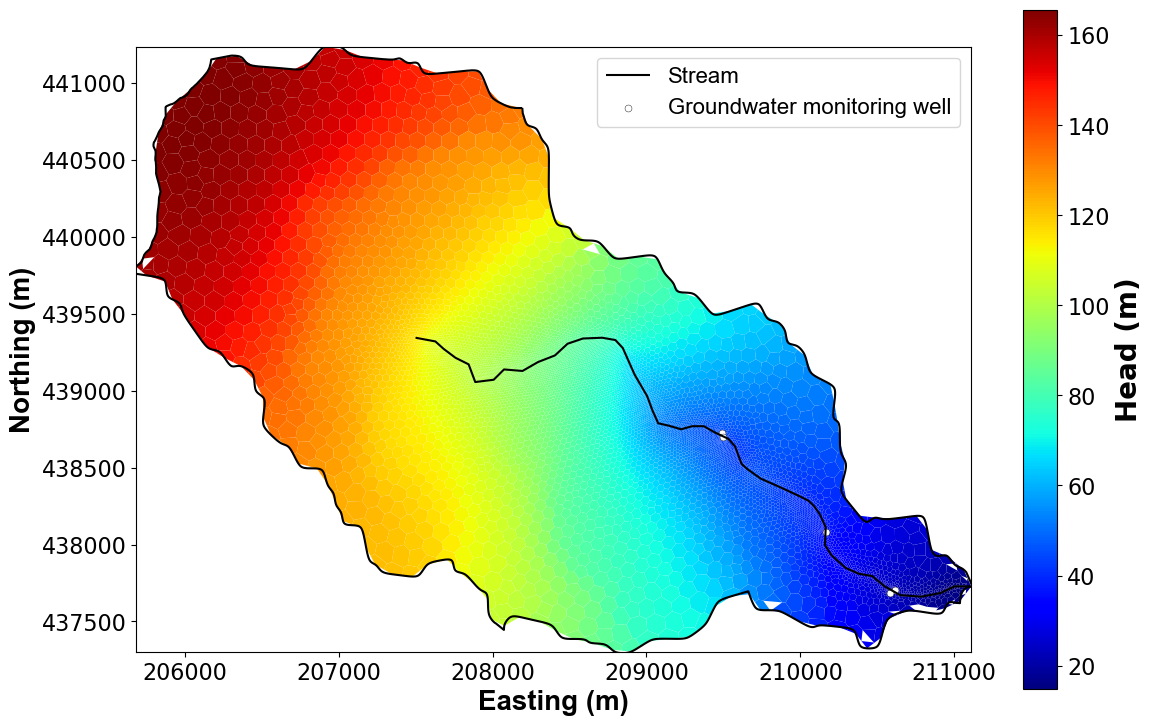

In [12]:
import flopy 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import geopandas 
font_title = {'fontsize': 18, 'fontweight': 'bold', 'family': 'Arial'} 
font_labels = {'fontsize': 20, 'fontweight': 'bold', 'family': 'Arial'} 
font_legend = {'size': 16, 'family': 'Arial'} 
sim_path = './Pyeongjung/model/mf/MODFLOW 6/sim' 
sim_name = 'flow.nam' 
sim = flopy.mf6.MFSimulation.load(sim_name=sim_name, sim_ws=sim_path) 
gwf = sim.get_model() 
headobj = flopy.utils.HeadFile('./Pyeongjung/model/mf/MODFLOW 6/sim/flow_output/flow.hds') 
times = headobj.get_times() 
head = headobj.get_data(totim=times[0], mflay=2) 
fig, ax = plt.subplots(figsize=(12,10)) 
mapview = flopy.plot.PlotMapView(model=gwf) 
collection = mapview.plot_array(head, cmap='jet') 
cbar = plt.colorbar(collection, ax=ax, shrink=0.7) 
cbar.set_label('Head (m)', fontsize=20, fontweight='bold') 
cbar.ax.tick_params(labelsize=16) 
stream = geopandas.read_file('./Pyeongjung/river_5186.shp') 
stream.plot(ax=plt.gca(), color='black', linewidth=1.5, label='Stream', zorder=4) 
boundary = geopandas.read_file('./Pyeongjung/PJ_EPSG5186.shp') 
boundary.plot(ax=plt.gca(), color='none', linewidth=1.5) 
wells_df = pd.read_csv('./Pyeongjung/Observation_3.csv') 
ax.scatter(wells_df['X'], wells_df['Y'], 25, marker='o', color='w', edgecolor = 'k', label='Groundwater monitoring well', lw=0.3) 

plt.xlabel("Easting (m)", fontdict=font_labels) 
plt.ylabel("Northing (m)", fontdict=font_labels) 
plt.legend(prop=font_legend) 
ax.tick_params(axis='both', which='major', labelsize=16) 
plt.tight_layout() 
plt.savefig('./head_distribution_2.tif', dpi=400)

In [16]:
import flopy
import numpy as np
import pandas as pd
from pathlib import Path

# ========= Paths =========
model_ws = './Pyeongjung/mf_7/MODFLOW 6/flow'
cbc_path = './Pyeongjung/mf_7/MODFLOW 6/flow/flow_output/flow.cbc'
outdir = Path('./Pyeongjung/outputs'); outdir.mkdir(parents=True, exist_ok=True)

# ========= Load sim/model/grid & CBC =========
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws, verbosity_level=0)
gwf = sim.get_model()
grid = gwf.modelgrid
cbc  = flopy.utils.CellBudgetFile(cbc_path, precision='double')

# -------- Helpers --------
def infer_zero_based(nodes, nnodes):
    """Make nodes 0-based if they look 1-based."""
    nodes = np.asarray(nodes, dtype=int)
    if nodes.size == 0:
        return nodes
    if nodes.max() >= nnodes:  # common hint of 1-based indexing in some outputs
        return nodes - 1
    return nodes

def nodes_to_xy(nodes, grid):
    """
    Return x,y for given global node ids across:
      - Structured (DIS)
      - VertexGrid (DISV)
      - Unstructured (DISU)
    Robust to x/y arrays that are length nnodes or length ncpl (per-layer).
    """
    nodes = np.asarray(nodes, dtype=int)
    nnodes = grid.nnodes
    nodes = infer_zero_based(nodes, nnodes)

    x_all = np.asarray(grid.xcellcenters).reshape(-1)
    y_all = np.asarray(grid.ycellcenters).reshape(-1)

    # Case A: x/y provided for every node (best-case; DISU often like this)
    if x_all.size == nnodes and y_all.size == nnodes:
        return x_all[nodes], y_all[nodes]

    # Identify grid type and layer layout
    grid_type = getattr(grid, "grid_type", "").lower()
    nlay = getattr(grid, "nlay", None)

    # For DIS (structured)
    if "structured" in grid_type or (hasattr(grid, "nrow") and hasattr(grid, "ncol")):
        nrow, ncol = grid.nrow, grid.ncol
        k = nodes // (nrow * ncol)
        rem = nodes % (nrow * ncol)
        i = rem // ncol
        j = rem % ncol
        # DIS structured x/y are 2D (nrow, ncol)
        x2d = np.asarray(grid.xcellcenters)
        y2d = np.asarray(grid.ycellcenters)
        return x2d[i, j], y2d[i, j]

    # For DISV / Vertex grid or Unstructured where x/y per-layer only
    # Derive ncpl per layer
    ncpl_attr = grid.ncpl
    if np.isscalar(ncpl_attr):
        ncpl_arr = np.repeat(int(ncpl_attr), nlay if nlay is not None else 1).astype(int)
    else:
        ncpl_arr = np.asarray(ncpl_attr, dtype=int)

    # If x_all has one layer's worth of centers (common in DISV), reuse per layer
    if x_all.size == ncpl_arr[0]:
        # map node -> (layer, icpl)
        # build cumulative layer starts in "node" indexing space
        layer_starts = np.r_[0, np.cumsum(ncpl_arr)[:-1]]
        # find layer k via searchsorted
        # Since nodes are 0..nnodes-1 in increasing order by layer,
        # we can compute k by comparing with layer_starts.
        # Vectorized approach:
        # For each node n, k = max index where layer_starts <= n
        k = np.searchsorted(layer_starts, nodes, side='right') - 1
        icpl = nodes - layer_starts[k]
        x = x_all[icpl]
        y = y_all[icpl]
        return x, y

    # Fallback: if sizes don’t match any expected pattern, return NaNs
    return (np.full(nodes.shape, np.nan), np.full(nodes.shape, np.nan))

# ========= Collect RIV time series =========
kstpkper_list = cbc.get_kstpkper()   # [(kstp, kper), ...] in file order
times = cbc.get_times()              # [totim, ...]      same order

records = []  # (totim, kper, kstp, nodes_array, q_array)
river_nodes_all = []

for i, (kstp, kper) in enumerate(kstpkper_list):
    rec = cbc.get_data(text='RIV', kstpkper=(kstp, kper))
    if not rec or rec[0].size == 0:
        continue
    arr = rec[0]
    nodes_i = arr['node']
    q_i     = arr['q']
    records.append((times[i], kper, kstp, nodes_i, q_i))
    river_nodes_all.append(nodes_i)

if not records:
    raise RuntimeError("No RIV records found. Ensure RIV has SAVE_FLOWS and CBC is written for the steps of interest.")

# Unique RIV nodes (in model indexing)
river_nodes = np.unique(np.concatenate(river_nodes_all)) if river_nodes_all else np.array([], dtype=int)
river_nodes = infer_zero_based(river_nodes, grid.nnodes)

# ========= Build tidy long-format =========
long_parts = []
for totim, kper, kstp, nodes_i, q_i in records:
    nodes_i = infer_zero_based(nodes_i, grid.nnodes)
    df_i = pd.DataFrame({
        'totim': float(totim),
        'kper': int(kper),
        'kstp': int(kstp),
        'node': nodes_i.astype(int),
        'q_m3d': q_i.astype(float)
    })
    long_parts.append(df_i)

ts_long = pd.concat(long_parts, ignore_index=True)
ts_long = ts_long[['totim','kper','kstp','node','q_m3d']]

# ========= Attach node coordinates (robust) =========
# Compute XY only for the nodes that actually appear
x_riv, y_riv = nodes_to_xy(river_nodes, grid)
meta = pd.DataFrame({'node': river_nodes, 'x': x_riv, 'y': y_riv})
ts_long = ts_long.merge(meta, on='node', how='left')
# ========= Wide-format convenience =========
ts_wide = ts_long.pivot_table(index='totim', columns='node', values='q_m3d', aggfunc='first').sort_index()

# ========= Save CSVs =========
long_path = outdir / 'riv_exchange_flux_timeseries_long_pump_well68_pmpdecrease.csv'
wide_path = outdir / 'riv_exchange_flux_timeseries_wide_pump_well68_pmpdecrease.csv'
meta_path = outdir / 'riv_nodes_metadata_2_pump_well68_pmpdecrease.csv'

ts_long.to_csv(long_path, index=False, float_format='%.6f')
ts_wide.to_csv(wide_path, float_format='%.6f')
meta.to_csv(meta_path, index=False)

print(f"[Saved] {long_path}")
print(f"[Saved] {wide_path}")
print(f"[Saved] {meta_path}")


[Saved] Pyeongjung\outputs\riv_exchange_flux_timeseries_long_pump_well68_pmpdecrease.csv
[Saved] Pyeongjung\outputs\riv_exchange_flux_timeseries_wide_pump_well68_pmpdecrease.csv
[Saved] Pyeongjung\outputs\riv_nodes_metadata_2_pump_well68_pmpdecrease.csv


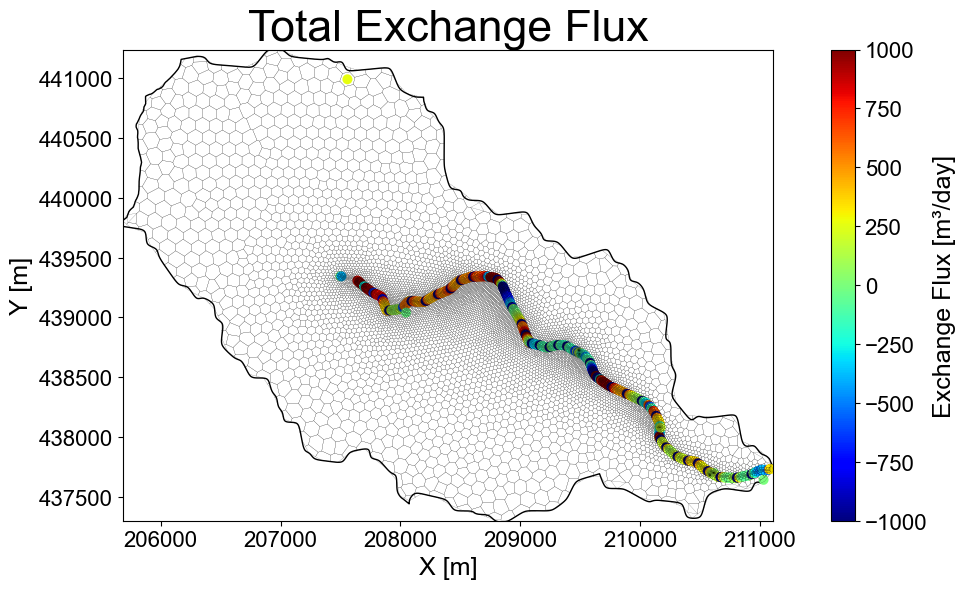

In [17]:
import flopy
import matplotlib.pyplot as plt
import numpy as np
import geopandas
from shapely.geometry import Point
import matplotlib.colors as mcolors

#Load the model
model_ws = './Pyeongjung/mf_4/MODFLOW 6/flow'
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws, verbosity_level=0)
gwf = sim.get_model()  # Assumes one GWF model

# === 2. Grid and CBC ===
grid = gwf.modelgrid  # VertexGrid
cbc = flopy.utils.CellBudgetFile('./Pyeongjung/mf_5/MODFLOW 6/flow/flow_output/flow.cbc', precision='double')

# === 3. Extract RIV flux ===
kstpkper = (0, 0)
rivdata = cbc.get_data(text='RIV', kstpkper=kstpkper)[0]

# === 4. Assign flux to full 3D array
riv_flux = np.full(grid.nnodes, np.nan)
riv_flux[rivdata['node']] = rivdata['q']

# === 5. Determine the number of cells in one layer ===
try:
    # Try treating ncpl as array
    ncpl = grid.ncpl
    layer = 0
    start = sum(ncpl[:layer])
    end = start + ncpl[layer]
except TypeError:
    # ncpl is int, structured vertically
    ncpl = grid.ncpl
    layer = 0
    start = layer * ncpl
    end = (layer + 1) * ncpl

# === 6. Slice flux and coordinates for layer 0 ===
riv_flux_layer0 = riv_flux[start:end]
xc = grid.xcellcenters[start:end]
yc = grid.ycellcenters[start:end]

# Load shapefile
shapefile = './Pyeongjung/PJ_EPSG5186.shp'
map_gdf = geopandas.read_file(shapefile)

# === 5. Create GeoDataFrame for RIV Flux Points ===
riv_points = geopandas.GeoDataFrame({
    'riv_flux': riv_flux_layer0
}, geometry=[Point(x, y) for x, y in zip(xc, yc)], crs=map_gdf.crs)

# === 2. Font settings ===
font_family = 'Arial'        # Or 'Times New Roman', 'DejaVu Sans', etc.
title_fontsize = 32
label_fontsize = 18
tick_fontsize = 16
colorbar_labelsize = 18
colorbar_ticksize = 16

# === 6. Plot Shapefile + RIV Flux ===
fig, ax = plt.subplots(figsize=(12, 6))

# === Plot RIV points ===
#riv_points.plot(ax=ax, column='riv_flux', cmap='Blues_r',
                #markersize=10, edgecolor='b', legend=True, vmin=0, vmax=10)

# Plot shapefile map (e.g., watershed boundary)
map_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)

# === Plot model grid ===
gwf.modelgrid.plot(ax=ax, linewidth=0.1, edgecolor='black', facecolor='none')

# === Plot RIV flux points (with filled color) ===
sc = ax.scatter(
    riv_points.geometry.x,  # X-coordinates
    riv_points.geometry.y,  # Y-coordinates
    c=riv_points['riv_flux'],  # Fill color by flux value
    cmap='jet',  # Choose colormap
    s=50,             # Marker size
    #edgecolor='k',    # Optional: black border
    linewidth=0.1,     # Thin edge for clarity
    vmin=-1000,
    vmax=1000)

# === Add colorbar ===
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Exchange Flux [m³/day]", fontsize=colorbar_labelsize, family=font_family)
cbar.ax.tick_params(labelsize=colorbar_ticksize)
for label in cbar.ax.get_yticklabels():
    label.set_family(font_family)

# === 5. Customize plot text ===
ax.set_title("Total Exchange Flux", fontsize=title_fontsize, family=font_family)
ax.set_xlabel("X [m]", fontsize=label_fontsize, family=font_family)
ax.set_ylabel("Y [m]", fontsize=label_fontsize, family=font_family)

ax.tick_params(axis='both', labelsize=tick_fontsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family(font_family)

# === 6. Final layout ===
ax.set_aspect('equal')
#plt.grid(True)
plt.tight_layout()
#plt.savefig('./Pyeongjung/Exchange_flux_Revised.tif', dpi=300)
plt.show()

In [18]:
import flopy
from flopy.utils import CellBudgetFile
from pathlib import Path
cb = CellBudgetFile(r"Pyeongjung/mf_2/MODFLOW 6/flow/flow_output/flow.cbc", precision="double")
print([n.decode().strip() for n in cb.get_unique_record_names()])

['FLOW-JA-FACE', 'DATA-SPDIS', 'DATA-SAT', 'RIV', 'GHB', 'RCH']


# Backward Particle Tracking

In [19]:
from pathlib import Path
import os, tempfile, shutil
import numpy as np
import flopy
from flopy.utils import binaryfile as bf

# ============================================================
# USER SETTINGS
# ============================================================
workspace_gwf = Path(r"D:\flopy\Pyeongjung\mf_4\MODFLOW 6\flow")
workspace_out = workspace_gwf / "flow_output"
workspace_prt = workspace_out / "prt_backward_new"

gwf_name = "flow"
headfile = workspace_out / "flow.hds"
cbcfile  = workspace_out / "flow.cbc"

# reversed files (for backward tracking)
head_bkwd = workspace_out / "flow_bkwd.hds"
cbc_bkwd  = workspace_out / "flow_bkwd.cbc"

# particles: (layer, icpl) in python 0-based
start_cellids = [(2, 322), (2, 323), (2, 363), (2, 364)]
particles_per_cell = 200
porosity = 0.10

# MF6 executable
mf6_exe = './mf6.7.0_win64/bin/mf6.exe'

# release times in the *reversed* simulation (0.0 = beginning of reversed run)
releasetimes = [1.0] 

# 0) Prevent WinError 17 during reverse() by forcing TEMP to output drive

workspace_prt.mkdir(parents=True, exist_ok=True)

out_drive = workspace_out.resolve().drive 
tmpdir = Path(out_drive + r"\flopy_temp")
tmpdir.mkdir(parents=True, exist_ok=True)

os.environ["TEMP"] = str(tmpdir)
os.environ["TMP"]  = str(tmpdir)
tempfile.tempdir = None

print("FloPy version:", flopy.__version__)
print("TEMP =", os.environ["TEMP"])
print("tempfile.gettempdir() =", tempfile.gettempdir())

# 1) Load existing GWF (DISV + TDIS)

gwf_sim = flopy.mf6.MFSimulation.load(sim_ws=str(workspace_gwf), exe_name=mf6_exe)
gwf = gwf_sim.get_model(gwf_name)
if gwf is None:
    raise RuntimeError(f'Could not find GWF model "{gwf_name}". Available: {gwf_sim.model_names}')

disv = gwf.get_package("disv")
if disv is None:
    raise RuntimeError("DISV package not found in GWF model.")

tdis = gwf_sim.get_package("tdis")
perioddata = tdis.perioddata.get_data()

# 2) Reverse head & budget (must exist)

if not headfile.exists():
    raise FileNotFoundError(headfile)
if not cbcfile.exists():
    raise FileNotFoundError(cbcfile)

print("\nReversing head/budget for backward tracking...")
bf.HeadFile(str(headfile), tdis=tdis).reverse(str(head_bkwd))
bf.CellBudgetFile(str(cbcfile), tdis=tdis).reverse(str(cbc_bkwd))
print("  wrote:", head_bkwd)
print("  wrote:", cbc_bkwd)


# 3) Find GWFGRID (*.grb) for ICELLTYPE (required with LOCAL_Z)

grb_candidates = list(workspace_gwf.glob("*.grb")) + list(workspace_out.glob("*.grb"))
if not grb_candidates:
    raise FileNotFoundError("No *.grb (binary grid) file found. Needed for PRT (ICELLTYPE).")
grbfile = grb_candidates[0]
print("Using GRB:", grbfile)

# copy reversed files + grb into PRT workspace
shutil.copy2(head_bkwd, workspace_prt / head_bkwd.name)
shutil.copy2(cbc_bkwd,  workspace_prt / cbc_bkwd.name)
shutil.copy2(grbfile,   workspace_prt / grbfile.name)

# 4) Build PRT-only simulation

prt_sim = flopy.mf6.MFSimulation(
    sim_name="prt_backward_sim",
    sim_ws=str(workspace_prt),
    exe_name=mf6_exe,)

flopy.mf6.ModflowTdis(
    prt_sim,
    time_units=tdis.time_units.get_data(),
    nper=len(perioddata),
    perioddata=perioddata,)

prt = flopy.mf6.ModflowPrt(prt_sim, modelname="prt", model_nam_file="prt.nam", exe_name=mf6_exe)

# DISV for PRT from GWF DISV
disv_kwargs = dict(
    nlay=disv.nlay.get_data(),
    ncpl=disv.ncpl.get_data(),
    nvert=disv.nvert.get_data(),
    vertices=disv.vertices.get_data(),
    cell2d=disv.cell2d.get_data(),
    top=disv.top.get_data(),
    botm=disv.botm.get_data(),)
idomain = disv.idomain.get_data()
if isinstance(idomain, np.ndarray):
    disv_kwargs["idomain"] = idomain

flopy.mf6.ModflowPrtdisv(prt, **disv_kwargs)

# porosity
flopy.mf6.ModflowPrtmip(prt, porosity=porosity)

# FMI: use reversed files + grid
fmi_pd = [
    ("GWFHEAD", head_bkwd.name),
    ("GWFBUDGET", cbc_bkwd.name),
    ("GWFGRID", grbfile.name),
]
flopy.mf6.ModflowPrtfmi(prt, packagedata=fmi_pd)

# OC
flopy.mf6.ModflowPrtoc(
    prt,
    pname="oc",
    budget_filerecord=[("prt.bud",)],
    saverecord=[("BUDGET", "ALL")],
    track_filerecord=[("prt.trk",)],
    trackcsv_filerecord=[("prt.trk.csv",)],
)

# EMS solver
ems = flopy.mf6.ModflowEms(
    prt_sim,
    pname="ems"
)
prt_sim.register_solution_package(ems, [prt.name])

# IMS solver (safe default)
#ims = flopy.mf6.ModflowIms(
#    prt_sim,
#    pname="ims",
#    print_option="SUMMARY",
#    complexity="SIMPLE",
#)
#prt_sim.register_solution_package(ims, [prt.name])

# 5) Build PRP release points
#    Use DISV cell2d centroid (xc,yc) to avoid "point not in cell" errors
cell2d = disv.cell2d.get_data()
cell2d_xy = {int(rec[0]): (float(rec[1]), float(rec[2])) for rec in cell2d}

releasepts_raw = []
for (k0, icpl0) in start_cellids:
    k = k0           # MF6 1-based layer
    icell2d = icpl0 + 1  # MF6 1-based cell2d id (assumed)

    if icell2d not in cell2d_xy:
        raise ValueError(f"cell2d id {icell2d} not found in DISV cell2d table. Check start_cellids indexing.")

    x0, y0 = cell2d_xy[icell2d]

    for _ in range(particles_per_cell):
        xrpt, yrpt = x0, y0
        zrpt = 0.5 
        releasepts_raw.append((k, icell2d, xrpt, yrpt, zrpt))

# Force irptno to 1..N
releasepts = [(i, k, icell2d, x, y, z)
              for i, (k, icell2d, x, y, z) in enumerate(releasepts_raw, start=0)]

# 6) PRP with explicit releasetimes (new FloPy)
prp = flopy.mf6.ModflowPrtprp(
    prt,
    pname="prp",
    nreleasepts=len(releasepts),
    packagedata=releasepts,
    # explicit release times
    nreleasetimes=len(releasetimes),
    releasetimes=releasetimes,
    # recommended options
    local_z=True,
    #track_filerecord=[("prt.trk",)],
    #trackcsv_filerecord=[("prt.trk.csv",)],
)

# sanity check: ensure PRP attached
print("\nPRT packages:", prt.package_names)
assert prt.get_package("prp") is not None, "PRP is not attached to PRT model."

# 7) Write & run
prt_sim.write_simulation()

# quick check that PRP is referenced in prt.nam
nam_txt = (workspace_prt / "prt.nam").read_text(errors="ignore").upper()
print("PRP6 in prt.nam? ->", ("PRP6" in nam_txt))

success, buff = prt_sim.run_simulation(silent=False, report=True)
print("success =", success)
if not success:
    print("\n".join(buff[-200:]))
    raise RuntimeError("PRT simulation failed.")

print("\nDone. Files in PRT workspace:")
for p in sorted(workspace_prt.glob("*")):
    print(" ", p.name)

print("\nExpected track files:")
print("  ", workspace_prt / "prt.trk")
print("  ", workspace_prt / "prt.trk.csv")


FloPy version: 3.10.0
TEMP = D:\flopy_temp
tempfile.gettempdir() = D:\flopy_temp
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package disv...
    loading package npf...
    loading package ic...
    loading package oc...
    loading package rch...
    loading package riv...
    loading package ghb...
    loading package wel...
  loading solution package flow...

Reversing head/budget for backward tracking...
  wrote: D:\flopy\Pyeongjung\mf_4\MODFLOW 6\flow\flow_output\flow_bkwd.hds
  wrote: D:\flopy\Pyeongjung\mf_4\MODFLOW 6\flow\flow_output\flow_bkwd.cbc
Using GRB: D:\flopy\Pyeongjung\mf_4\MODFLOW 6\flow\flow.disv.grb


c:\Users\SUHHO LEE\AppData\Local\Programs\Python\Python311\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(



PRT packages: ['disv', 'mip', 'fmi', 'oc', 'prp']
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ems...
  writing model prt...
    writing model name file...
    writing package disv...
    writing package mip...
    writing package fmi...
    writing package oc...
    writing package prp...
PRP6 in prt.nam? -> True
FloPy is using the following executable to run the model: ..\..\..\..\..\..\mf6.7.0_win64\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Build 20220226_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 

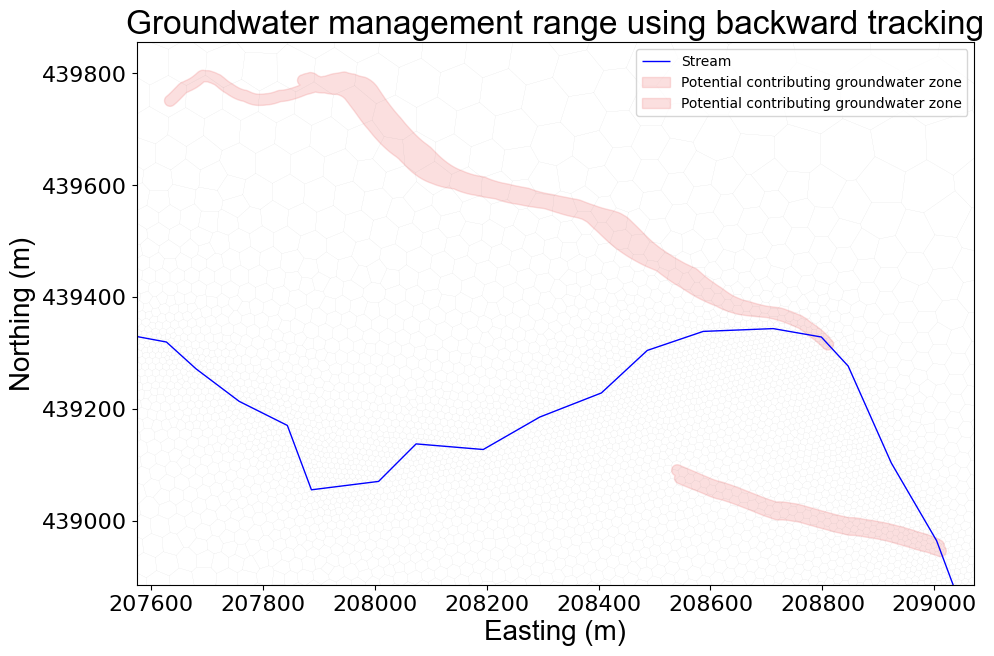

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import flopy
import numpy as np
import geopandas
from shapely.geometry import LineString, Point
from shapely.ops import unary_union

# -----------------------
# Load model grid for PlotMapView
# -----------------------
sim_ws   = r"Pyeongjung/mf_4/MODFLOW 6/flow"
gwf_name = "flow"

sim = flopy.mf6.MFSimulation.load(sim_ws=sim_ws, verbosity_level=0)
gwf = sim.get_model(gwf_name)

# -----------------------
# Read track CSV
# -----------------------
df = pd.read_csv('./Pyeongjung/mf_4/MODFLOW 6/flow/flow_output/prt_backward_new/prt.trk.csv')


# pathline grouping (너 컬럼 기준: imdl, iprp, irpt)
group_cols = ["imdl", "iprp", "irpt"]

# 1) pathline을 LineString 리스트로 만들기
lines = []
for _, g in df.groupby(group_cols):
    g = g.sort_values("t")
    xy = np.column_stack([g["x"].to_numpy(), g["y"].to_numpy()])
    if len(xy) < 2:
        continue

    # 연속 중복점 제거(라인 에러/불필요한 점 방지)
    mask = np.any(np.diff(xy, axis=0) != 0, axis=1)
    xy2 = np.vstack([xy[0], xy[1:][mask]])
    if len(xy2) >= 2:
        lines.append(LineString(xy2))

# 2) 라인을 포함하는 폴리곤 만들기 (buffer -> union)
buffer_dist = 10.0  # << 여기 조절! (모델 좌표 단위: 보통 m)
polys = [ln.buffer(buffer_dist, cap_style=1, join_style=1) for ln in lines]
area = unary_union(polys)  # Polygon or MultiPolygon

# 3) 플롯
fig, ax = plt.subplots(figsize=(10, 8))

pmv = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=0)
pmv.plot_grid(lw=0.1, alpha=0.2)
stream = geopandas.read_file('./Pyeongjung/river_5186.shp')
stream.plot(ax=ax, linewidth=1.0, color='b', label="Stream")
# (a) 폴리곤 먼저 채우기
def fill_poly(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, color = 'lightcoral', alpha=0.25)
    elif geom.geom_type == "MultiPolygon":
        for p in geom.geoms:
            x, y = p.exterior.xy
            ax.fill(x, y, color = 'lightcoral', alpha=0.25, label='Potential contributing groundwater zone')

fill_poly(area)

# (b) 그 위에 라인 다시 그리기
#for ln in lines:
#    x, y = ln.xy
#    ax.plot(x, y, lw=1.0, alpha=0.9)

# === 2. Font settings ===
font_family = 'Arial'        # Or 'Times New Roman', 'DejaVu Sans', etc.
title_fontsize = 32
label_fontsize = 18
tick_fontsize = 16
# -----------------------
# 4) 자동 zoom: polygon bounds 기준으로 범위 축소
# -----------------------
minx, miny, maxx, maxy = area.bounds

ax.tick_params(axis='both', which='major', labelsize=16) 
pad = 50.0  # 여백(m). 상황에 맞게 20~200 정도로 조절
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Easting (m)", fontsize=20, family='Arial')
ax.set_ylabel("Northing (m)", fontsize=20, family = 'Arial')
ax.set_title(f"Groundwater management range using backward tracking", fontsize=24, family='Arial')
ax.legend()
#plt.savefig('./Figure9b.tif', dpi=300)
plt.tight_layout()
plt.show()